<a href="https://colab.research.google.com/github/dr-dlr/ENOE/blob/main/ENOE_Shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# USANDO SHAP

#CHANGELOG (REGISTRO DE CAMBIOS)

### Refactorización del Modelo Predictivo (Tesis Doctoral)

ETL (Preparación de datos)

  - [ELIMINADO] Carga redundante de datos:
      - Original: SE cargaba el dataset enoe_final.csv al principio y luego lo
        a la mitad del script antes de dicotomizar.
      - Nuevo: Se unificó en una sola carga al inicio del script.

  - [MODIFICADO] Imputación de anios_estudio (Valores 99):
      - Original: Se calculaba el promedio (media) de los años de estudio y lo
        luego se redeondeaba.
      - Nuevo: Se cambió por el cálculo de la mediana (.median()).
      - Razón: En variables socioeconómicas (como educación o ingresos), la
        media es muy sensible a valores atípicos (outliers). La mediana es una
        medida estadísticamente más robusta y aceptada en la academia para
        imputar datos faltantes o no especificados.
  - [MEJORADO] Limpieza de tiene_jefe:
      - Original: Se hacía múltiples conversiones de tipo (to_numeric,
        astype('Int64'), astype(str)) a lo largo del código.
      - Cambio: Se consolidó en un solo bloque lógico: forzar a numérico,
        rellenar nulos con la moda y convertir a entero estándar (int).

Ingeniería de la Variable Objetivo (dependiente)

  - [REFACTORIZADO] Creación de la variable dicotómica:
      - Original: Primero se hacía 4 categorías (0, 1, 2, 3) usando percentiles,
        y muchas líneas después se unían en 0 y 1 mediante una función
        lambda.
      - Cambio: Se creó una única función clasificar_precariedad que evalúa
        directamente si el ingreso es menor/igual al percentil 33 (Precariedad
        = 0) o mayor (Competitivo = 1).
  - [AÑADIDO] Prevención estricta de Fuga de Datos (Data Leakage):
      - Original: Se mantenía la columna ingreso original en el DataFrame casi
        hasta el final.
      - Cambio: Se eliminó la columna ingreso inmediatamente después de crear
        target_precariedad para que el modelo no "vea las respuestas".

Preprocesamiento de Datos

  - [ELIMINADO] Uso de pd.get_dummies:
      - Original: Se usaba Pandas para convertir variables categóricas a numéricas (One-Hot Encoding).
      - Cambio: Se reemplazó por ColumnTransformer y OneHotEncoder de
        Scikit-Learn.
  - [AÑADIDO] Estandarización de variables numéricas:
      - Original: Las variables numéricas (edad, anios_estudio, hrs_trabajo)
        entraban crudas al modelo.
      - Cambio: Se añadió StandardScaler para poner todas las variables
        numéricas en la misma escala.

Modelado y Optimización (Machine Learning)

  - [CORREGIDO] Implementación de SMOTE (Balanceo de clases):
      - Original: Se importó SMOTE pero no fue aplicado en el código final.
      - Cambio: Se integró SMOTE dentro de un Pipeline de la librería imblearn.
  - [AÑADIDO] Validación Cruzada y Búsqueda de Hiperparámetros (GridSearchCV):
      - Original: Se entrenó un Random Forest con parámetros por defecto
        (n_estimators=100) y una sola semilla (random_state=42).
      - Cambio: Se implementó StratifiedKFold (5 particiones) y GridSearchCV
        para probar múltiples combinaciones de profundidad de árboles y número
        de estimadores.
Evaluación y Predictores (Interpretabilidad)

  - [AÑADIDO] Métricas de evaluación robustas:
      - Original: Se usaba Accuracy (Precisión global) y el Reporte de
        Clasificación.
      - Cambio: Se mantuvo el reporte, se mejoró visualmente la Matriz de
        Confusión y se añadió el ROC-AUC Score.
  - [ELIMINADO] Importancia de variables de Gini (feature_importances_):
      - Original: Se usaba el método nativo de Random Forest para graficar el
        "Peso Predictivo".
      - Cambio: Se eliminó por completo.
  - [AÑADIDO] Valores SHAP (Shapley Additive exPlanations):
      - Original: No existía.
      - Cambio: Se implementó el explicador SHAP (TreeExplainer), generando
        gráficos de resumen (Summary Plot) y de dependencia (Dependence Plot). Actualmente es el estado del arte (State of the Art) en interpretabilidad de Inteligencia Artificial. Basado en la Teoría de Juegos (Premio Nobel
        de Economía), SHAP calcula la contribución marginal exacta de cada
        variable. Esto permite afirmar con rigor doctoral no solo qué
        variable importa, sino cómo empuja la predicción (precariedad o
        salario competitivo).

Iniciando carga y limpieza de datos...
Construyendo el Pipeline de Machine Learning...
Iniciando Validación Cruzada (GridSearchCV)... Esto puede tomar unos minutos.
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Mejores hiperparámetros encontrados:
{'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

REPORTE DE CLASIFICACIÓN (DATOS DE PRUEBA)
                 precision    recall  f1-score   support

Precariedad (0)       0.71      0.68      0.69       170
Competitivo (1)       0.50      0.54      0.52       103

       accuracy                           0.63       273
      macro avg       0.61      0.61      0.61       273
   weighted avg       0.63      0.63      0.63       273

ROC-AUC Score: 0.6991


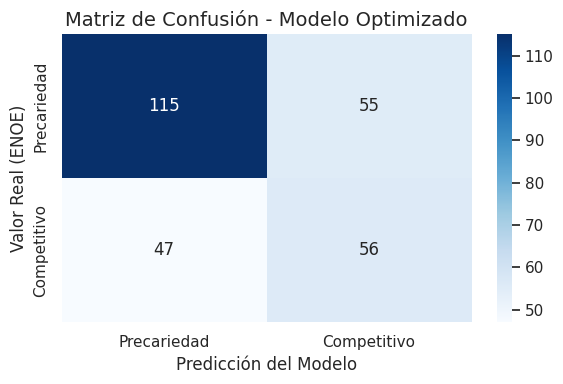


Calculando Valores SHAP para la explicabilidad del modelo...


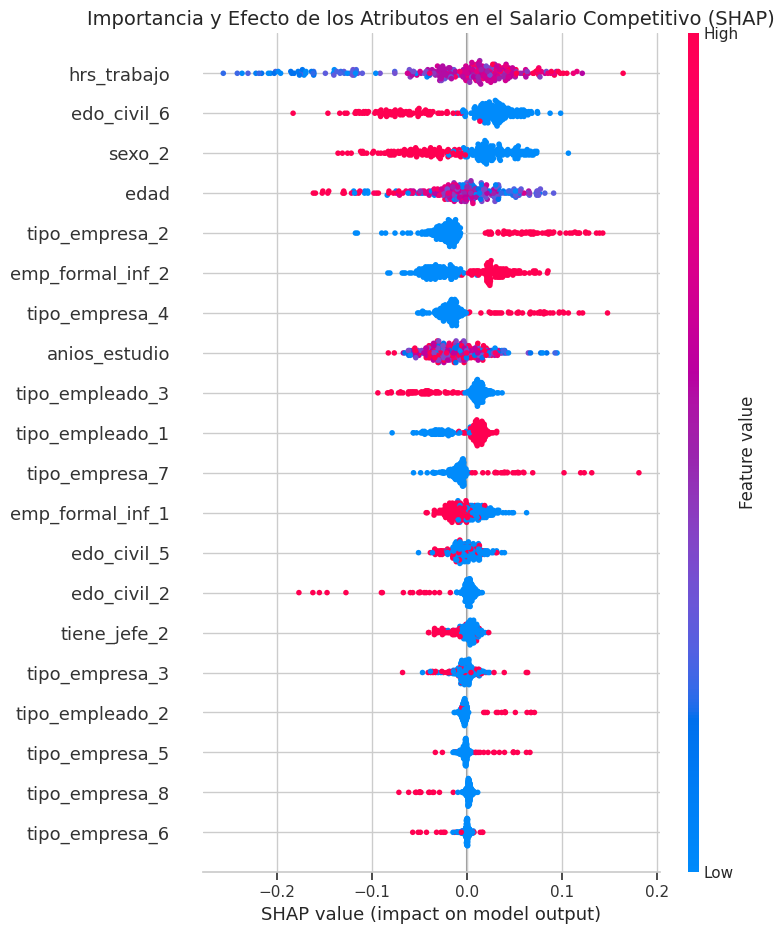

<Figure size 800x500 with 0 Axes>

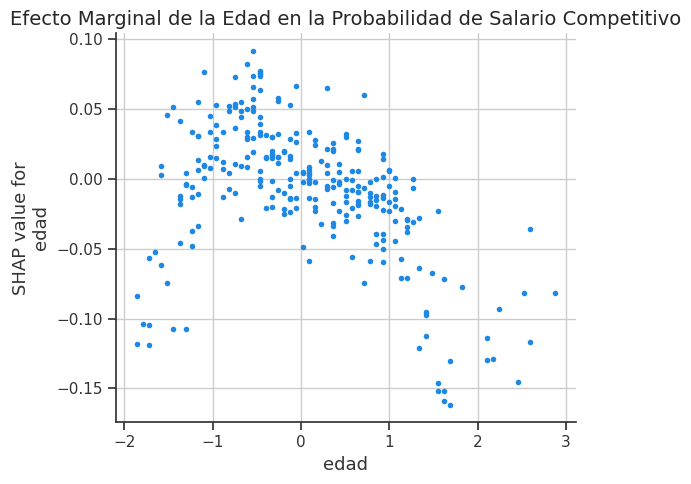

<Figure size 800x500 with 0 Axes>

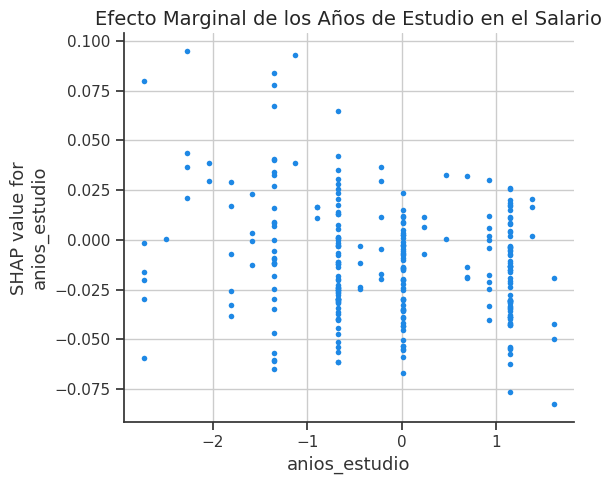

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import shap

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print("Iniciando carga y limpieza de datos...")

df = pd.read_csv('/content/enoe_final.csv')

df['tiene_jefe'] = pd.to_numeric(df['tiene_jefe'], errors='coerce')
moda_jefe = df['tiene_jefe'].mode()[0]
df['tiene_jefe'] = df['tiene_jefe'].fillna(moda_jefe).astype(int)

mediana_estudio = df.loc[df['anios_estudio'] != 99, 'anios_estudio'].median()
df.loc[df['anios_estudio'] == 99, 'anios_estudio'] = mediana_estudio

columnas_a_eliminar = ['mpio', 'estrato', 'pea_si_no']
df = df.drop(columns=columnas_a_eliminar, errors='ignore')

ingresos_pos = df.loc[df['ingreso'] > 0, 'ingreso']
p33 = ingresos_pos.quantile(0.33)

def clasificar_precariedad(ingreso):
    if pd.isna(ingreso) or ingreso <= p33:
        return 0
    else:
        return 1

df['target_precariedad'] = df['ingreso'].apply(clasificar_precariedad)

X = df.drop(columns=['ingreso', 'target_precariedad'])
y = df['target_precariedad']

print("Construyendo el Pipeline de Machine Learning...")

cat_cols =['sexo', 'edo_civil', 'tipo_empleado', 'tipo_empresa', 'emp_formal_inf', 'tiene_jefe']
num_cols =['edad', 'anios_estudio', 'hrs_trabajo']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

print("Iniciando Validación Cruzada (GridSearchCV)... Esto puede tomar unos minutos.")

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth':[10, 15, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"\nMejores hiperparámetros encontrados:\n{grid_search.best_params_}")

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN (DATOS DE PRUEBA)")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Precariedad (0)', 'Competitivo (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Precariedad', 'Competitivo'],
            yticklabels=['Precariedad', 'Competitivo'])
plt.title('Matriz de Confusión - Modelo Optimizado', fontsize=14)
plt.ylabel('Valor Real (ENOE)')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()

print("\nCalculando Valores SHAP para la explicabilidad del modelo...")

rf_final = best_model.named_steps['classifier']
preprocessor_final = best_model.named_steps['preprocessor']

X_test_transformed = preprocessor_final.transform(X_test)

cat_encoder = preprocessor_final.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_feature_names)

X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

explainer = shap.TreeExplainer(rf_final)
shap_values = explainer.shap_values(X_test_df)

plt.figure(figsize=(10, 6))
plt.title("Importancia y Efecto de los Atributos en el Salario Competitivo (SHAP)", fontsize=14)
shap.summary_plot(shap_values[:, :, 1], X_test_df, show=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
shap.dependence_plot("edad", shap_values[:, :, 1], X_test_df, show=False, interaction_index=None)
plt.title("Efecto Marginal de la Edad en la Probabilidad de Salario Competitivo", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
shap.dependence_plot("anios_estudio", shap_values[:, :, 1], X_test_df, show=False, interaction_index=None)
plt.title("Efecto Marginal de los Años de Estudio en el Salario", fontsize=14)
plt.tight_layout()
plt.show()

# CAMBIOS EN LAS PROPUESTAS DE POLÍTICAS PÚBLICAS

Al tiempo de analizar los predictores, la principal diferencia entre usar SHAP contra Importancia de Características yace en que el predictor principal ahora es horas de trabajo, sin embargo, sexo y edad siguen teniendo un gran peso prediciendo la precariedad laboral. Si bien el modelo tiene un AUC ROC de 0.7 (nivel ligeramente inferior al comunmente aceptado en la ciencia de datos), para el campo de las ciencias sociales es un valor sólido en su intención de predicción. Por otra parte, de acuerdo con las métricas aunque el modelo tiene dificultades para encontrar a las personas con un salario competitivo, es bastante más preciso para hallar personas en situación de precariedad, lo que es el objetivo principal del modelo.

En virtud de lo anterior, se mantienen las propuestas de políticas públicas mencionadas anteriormente:

### 2.1 Estímulos fiscales para empresas que otorguen el primer empleo.
Se pueden elegir diversas opciones para reducir la carga impositiva de los comercios a través de la contratación de mano de obra joven que necesite experiencia y capacitación, o las personas adultas mayores, ambos gurpos penalizados por la edad; algunos de estos incentivos pueden realizarse directamente a los impuestos al patrimonio como el predial; asimismo pueden hacer reducciones o condonaciones sobre los derechos por prestación de servicios en materia de permisos para el funcionamiento industrial, comercial o de servicios sobre el giro del comercio que contrate personas jóvenes o adultos mayores.

### 2.2 Subsidios de capacitación a empresas.
Contrario a políticas de primer empleo, donde el estado inserta al trabajador al mercado laboral, pueden elegirse de manera supletoria o complementaria, subsidios a la profesionalización de los trabajadores penalizados por el predictor de la edad considerando programas de adopción de competencias específicas para los sectores productivos del municipio o programas de reconversión de habilidades (reskilling) para personas mayores de 50 años.

Aunque a la luz de los nuevos hallazgos, estas propuestas pueden evolucionar con las siguientes características focalizadas a los demás predictores:

### 3.1 Estímulos fiscales adicionales a quienes decidan pasar al mercado formal.
Se sugiere la condonación por un periodo de por lo menos dos años sobre los derechos por prestación de servicios en materia de permisos para el funcionamiento industrial, comercial o de servicios y permisos para enajenación de bebidas alcohólicas (si el giro aplica), además de la ya comentada reducción de impestos al patrimonio, sobre el giro del comercio que se regularice y opte por cambiar de la informalidad laboral a la formalidad laboral.

### 3.2 Certificación sobre equidad salarial
Se propone, usando facultades de revisión, el otorgamiento de un distintivo a las empresas que demuestren no tener brechas salariales por género, y prioridad en procesos de contratación administrativa en caso de ser proveedores para el Gobierno del Estado.

### 3.3 Sistema municipal de cuidados y disminución de empleos de medio tiempo
El predictor de mayor peso son las horas laboradas, se asume que, a mayor cantidad de horas trabajadas, mayor la cantidad de la remuneración; sin embargo, en atención a los otros predictores, las mujeres sufren una penalización silenciosa al no poder destinar la misma cantidad que los hombres. La literatura advierte que aunque las mujeres laboran una cantidad mayor de horas que los hombres, parte de estas es en actividades no remuneradas como el cuidado del hogar y los dependientes económicos. El enfoque de esta medida versa sobre la creación de un sistema municipal de cuidados que libere a las mujeres de actividades no remuneradas para destinar más horas al trabajo remunerado.